<a href="https://colab.research.google.com/github/shivii2005/infrared-image-enhancement/blob/main/infrared_image_enhancement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:

!pip install torch torchvision opencv-python matplotlib

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import torchvision
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [7]:
import torchvision
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

print("Dataset size:", len(dataset))

100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s]


Dataset size: 50000


In [8]:
import torch
from torch.utils.data import Dataset
import torchvision.transforms as transforms
import random

class NoisyInfraredDataset(Dataset):
    def __init__(self, base_dataset, noise_factor=0.3):
        self.base_dataset = base_dataset
        self.noise_factor = noise_factor

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        clean_img, _ = self.base_dataset[idx]

        noise = torch.randn_like(clean_img) * self.noise_factor
        noisy_img = clean_img + noise
        noisy_img = torch.clamp(noisy_img, 0., 1.)

        return noisy_img, clean_img

In [9]:
noisy_dataset = NoisyInfraredDataset(dataset, noise_factor=0.4)

print("Noisy dataset ready")

Noisy dataset ready


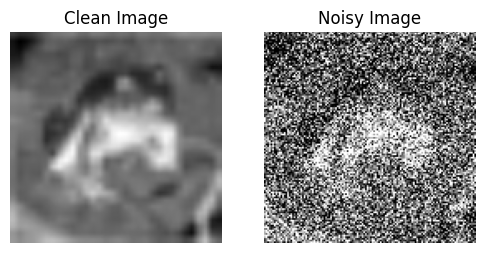

In [10]:
import matplotlib.pyplot as plt

noisy_img, clean_img = noisy_dataset[0]

plt.figure(figsize=(6,3))

plt.subplot(1,2,1)
plt.title("Clean Image")
plt.imshow(clean_img.squeeze(), cmap='gray')
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Noisy Image")
plt.imshow(noisy_img.squeeze(), cmap='gray')
plt.axis("off")

plt.show()

In [11]:
import torch.nn as nn

class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 1, 2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [12]:
model = DenoisingAutoencoder().to(device)
print(model)

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(32, 1, kernel_size=(2, 2), stride=(2, 2))
    (3): Sigmoid()
  )
)


In [56]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    drop_last=True
)

In [57]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Loss and Optimizer Ready")

Loss and Optimizer Ready


In [59]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for noisy_imgs, clean_imgs in train_loader:
        noisy_imgs = noisy_imgs.to(device)
        clean_imgs = clean_imgs.to(device)

        optimizer.zero_grad()

        outputs = model(noisy_imgs)

        loss_mse = criterion(outputs, clean_imgs)
        loss_edge = edge_loss(outputs, clean_imgs)
        loss_ssim = ssim_loss(outputs, clean_imgs)

        loss = loss_mse + 0.1 * loss_edge + 0.3 * loss_ssim

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/5], Loss: 0.0386
Epoch [2/5], Loss: 0.0367
Epoch [3/5], Loss: 0.0362
Epoch [4/5], Loss: 0.0352
Epoch [5/5], Loss: 0.0353


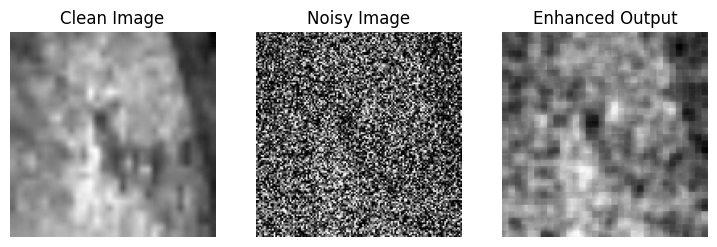

In [16]:
model.eval()

# Take one sample
noisy_img, clean_img = noisy_dataset[10]

with torch.no_grad():
    output = model(noisy_img.unsqueeze(0).to(device))
    output = output.squeeze().cpu()

plt.figure(figsize=(9,3))

plt.subplot(1,3,1)
plt.title("Clean Image")
plt.imshow(clean_img.squeeze(), cmap='gray')
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Noisy Image")
plt.imshow(noisy_img.squeeze(), cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Enhanced Output")
plt.imshow(output, cmap='gray')
plt.axis("off")

plt.show()

In [17]:
import torch.nn.functional as F
import math

def calculate_psnr(original, reconstructed):
    mse = F.mse_loss(reconstructed, original)
    if mse == 0:
        return 100
    psnr = 20 * math.log10(1.0 / math.sqrt(mse.item()))
    return psnr

In [18]:
# Make shapes identical
original = clean_img.unsqueeze(0).to(device)        # [1,1,128,128]
reconstructed = model(noisy_img.unsqueeze(0).to(device))

psnr_value = calculate_psnr(original, reconstructed)

print("PSNR:", psnr_value)

PSNR: 25.024658837273318


In [19]:
!pip install kaggle

In [20]:
import os

os.environ['KAGGLE_USERNAME'] = 'shivangigoutam'
os.environ['KAGGLE_KEY'] = 'KGAT_ec33560f2cf484efd8380e483e392788'

In [21]:
!kaggle datasets list -s infrared


ref                                                              title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
marcosgabriel/infrared-solar-modules                             Infrared Solar Modules                                15957525  2023-11-02 17:59:02.840000           2640         18  0.875            
pandrii000/hituav-a-highaltitude-infrared-thermal-dataset        HIT-UAV: A High-altitude Infrared Thermal Dataset    199874530  2023-02-01 11:54:16.263000           4877         48  1.0              
sshubam/insat3d-infrared-raw-cyclone-images-20132021             INSAT3D Infrared & Raw Cyclone Imagery (2012-2021)    45322098  2022-06-27 07:29:35.020000           2775         37  0.9411765    

In [22]:
!kaggle datasets download -d pandrii000/hituav-a-highaltitude-infrared-thermal-dataset

Dataset URL: https://www.kaggle.com/datasets/pandrii000/hituav-a-highaltitude-infrared-thermal-dataset
License(s): GNU Lesser General Public License 3.0
 78% 149M/191M [00:00<00:00, 1.56GB/s]
100% 191M/191M [00:00<00:00, 954MB/s] 


In [23]:
!unzip hituav-a-highaltitude-infrared-thermal-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: hit-uav/images/train/0_110_70_0_08486.jpg  
  inflating: hit-uav/images/train/0_110_80_0_03729.jpg  
  inflating: hit-uav/images/train/0_110_80_0_03734.jpg  
  inflating: hit-uav/images/train/0_110_80_0_08491.jpg  
  inflating: hit-uav/images/train/0_110_80_0_08512.jpg  
  inflating: hit-uav/images/train/0_110_80_0_08518.jpg  
  inflating: hit-uav/images/train/0_110_80_0_08520.jpg  
  inflating: hit-uav/images/train/0_110_80_0_08522.jpg  
  inflating: hit-uav/images/train/0_110_90_0_03784.jpg  
  inflating: hit-uav/images/train/0_110_90_0_03802.jpg  
  inflating: hit-uav/images/train/0_110_90_0_08527.jpg  
  inflating: hit-uav/images/train/0_110_90_0_08529.jpg  
  inflating: hit-uav/images/train/0_110_90_0_08532.jpg  
  inflating: hit-uav/images/train/0_110_90_0_08536.jpg  
  inflating: hit-uav/images/train/0_110_90_0_08542.jpg  
  inflating: hit-uav/images/train/0_110_90_0_08545.jpg  
  inflating: hit-uav/images/train/0_1

In [24]:
import os

for root, dirs, files in os.walk(".", topdown=True):
    print(root)
    break

.


In [25]:
!ls

data  hit-uav  hituav-a-highaltitude-infrared-thermal-dataset.zip  sample_data


In [26]:
!ls hit-uav

dataset.yaml  images  labels


In [27]:
!ls hit-uav/images/train | head

0_100_30_0_03280.jpg
0_100_30_0_03281.jpg
0_100_30_0_03284.jpg
0_100_30_0_03288.jpg
0_100_30_0_03289.jpg
0_100_30_0_03291.jpg
0_100_30_0_03292.jpg
0_100_30_0_03294.jpg
0_100_30_0_03298.jpg
0_100_30_0_03301.jpg


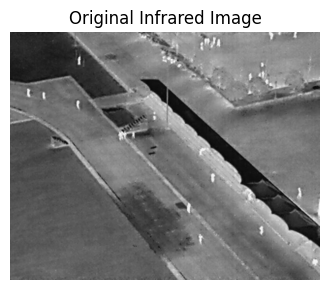

Image size: (640, 512)
Image mode: L


In [28]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

# Path to training images
train_path = "hit-uav/images/train"

# Pick random image
img_name = random.choice(os.listdir(train_path))
img_path = os.path.join(train_path, img_name)

# Load image
img = Image.open(img_path)

# Show image
plt.figure(figsize=(4,4))
plt.imshow(img, cmap='gray')
plt.title("Original Infrared Image")
plt.axis("off")
plt.show()

print("Image size:", img.size)
print("Image mode:", img.mode)

In [29]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import random

class InfraredDenoiseDataset(Dataset):
    def __init__(self, image_dir):
        self.image_dir = image_dir
        self.image_files = os.listdir(image_dir)

        self.transform = transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
        ])

    def add_noise(self, img):
        noise = torch.randn_like(img) * 0.1
        noisy_img = img + noise
        noisy_img = torch.clamp(noisy_img, 0., 1.)
        return noisy_img

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        image = Image.open(img_path).convert("L")
        image = self.transform(image)

        noisy_image = self.add_noise(image)

        return noisy_image, image

In [30]:
train_dataset = InfraredDenoiseDataset("hit-uav/images/train")
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

print("Total training images:", len(train_dataset))

Total training images: 2008


In [31]:
import torch.nn as nn

class InfraredAutoencoder(nn.Module):
    def __init__(self):
        super(InfraredAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, 2, stride=2),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 1, 2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = InfraredAutoencoder().to(device)

print(model)

InfraredAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): ConvTranspose2d(32, 1, kernel_size=(2, 2), stride=(2, 2))
    (5): Sigmoid()
  )
)


In [32]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5

In [33]:
for epoch in range(epochs):
    running_loss = 0.0

    for noisy_imgs, clean_imgs in train_loader:
        noisy_imgs = noisy_imgs.to(device)
        clean_imgs = clean_imgs.to(device)

        outputs = model(noisy_imgs)
        loss = criterion(outputs, clean_imgs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/5], Loss: 0.0073
Epoch [2/5], Loss: 0.0022
Epoch [3/5], Loss: 0.0019
Epoch [4/5], Loss: 0.0017
Epoch [5/5], Loss: 0.0016


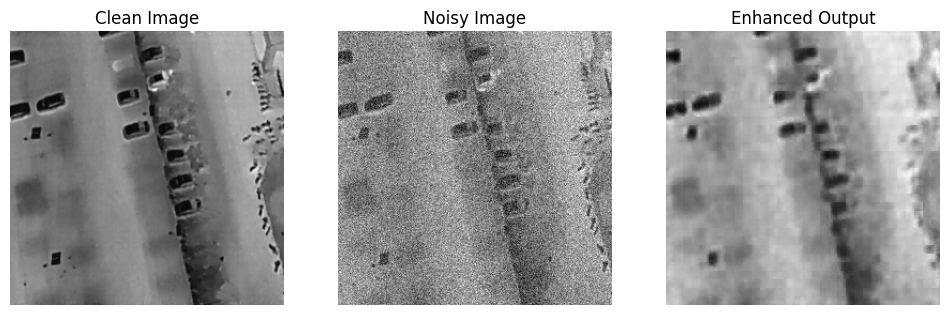

In [34]:
import matplotlib.pyplot as plt

# Get one batch
noisy_imgs, clean_imgs = next(iter(train_loader))

noisy = noisy_imgs[0].unsqueeze(0).to(device)
clean = clean_imgs[0].unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(noisy)

# Move to CPU
noisy = noisy.cpu().squeeze()
clean = clean.cpu().squeeze()
output = output.cpu().squeeze()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(clean, cmap='gray')
plt.title("Clean Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noisy, cmap='gray')
plt.title("Noisy Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(output, cmap='gray')
plt.title("Enhanced Output")
plt.axis("off")

plt.show()

In [35]:
import torch
import torch.nn as nn

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()

        # Encoder
        self.down1 = DoubleConv(1, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(256, 512)

        # Decoder
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):

        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        d3 = self.down3(p2)
        p3 = self.pool3(d3)

        bottleneck = self.bottleneck(p3)

        up3 = self.up3(bottleneck)
        up3 = torch.cat([up3, d3], dim=1)
        up3 = self.conv3(up3)

        up2 = self.up2(up3)
        up2 = torch.cat([up2, d2], dim=1)
        up2 = self.conv2(up2)

        up1 = self.up1(up2)
        up1 = torch.cat([up1, d1], dim=1)
        up1 = self.conv1(up1)

        return torch.sigmoid(self.final(up1))


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)

print("UNet Model Loaded")

UNet Model Loaded


In [36]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

epochs = 5

In [37]:
for epoch in range(epochs):
    running_loss = 0.0

    for noisy_imgs, clean_imgs in train_loader:
        noisy_imgs = noisy_imgs.to(device)
        clean_imgs = clean_imgs.to(device)

        outputs = model(noisy_imgs)
        loss = criterion(outputs, clean_imgs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/5], Loss: 0.0019
Epoch [2/5], Loss: 0.0012
Epoch [3/5], Loss: 0.0011
Epoch [4/5], Loss: 0.0010
Epoch [5/5], Loss: 0.0010


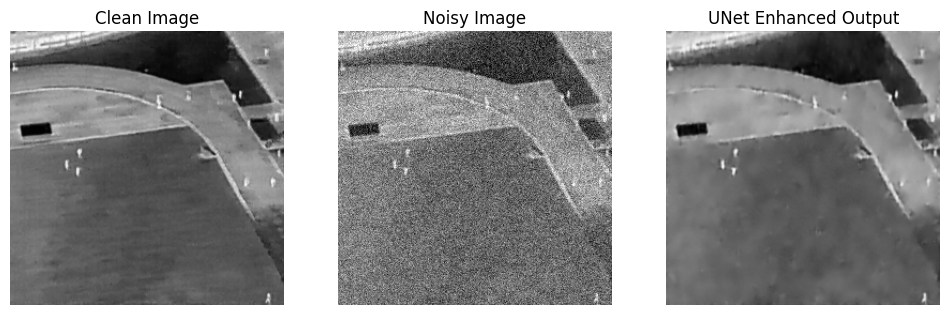

In [38]:
model.eval()

noisy_imgs, clean_imgs = next(iter(train_loader))

noisy = noisy_imgs[0].unsqueeze(0).to(device)
clean = clean_imgs[0].unsqueeze(0).to(device)

with torch.no_grad():
    output = model(noisy)

noisy = noisy.cpu().squeeze()
clean = clean.cpu().squeeze()
output = output.cpu().squeeze()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(clean, cmap='gray')
plt.title("Clean Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noisy, cmap='gray')
plt.title("Noisy Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(output, cmap='gray')
plt.title("UNet Enhanced Output")
plt.axis("off")

plt.show()

In [39]:
import torch.nn.functional as F
import math

def calculate_psnr(img1, img2):
    mse = F.mse_loss(img1, img2)
    if mse == 0:
        return 100
    return 20 * math.log10(1.0 / math.sqrt(mse))

psnr_value = calculate_psnr(clean.unsqueeze(0).unsqueeze(0).to(device),
                            output.unsqueeze(0).unsqueeze(0).to(device))

print("PSNR:", psnr_value)

PSNR: 31.914932811791008


In [40]:
!pip install pytorch-msssim

In [41]:
from pytorch_msssim import ssim

ssim_value = ssim(
    clean.unsqueeze(0).unsqueeze(0).to(device),
    output.unsqueeze(0).unsqueeze(0).to(device),
    data_range=1.0
)

print("SSIM:", ssim_value.item())

SSIM: 0.8759686350822449


In [42]:
import torch.nn.functional as F

def edge_loss(pred, target):
    sobel_x = torch.tensor([[[-1,0,1],
                             [-2,0,2],
                             [-1,0,1]]], dtype=torch.float32).to(device)

    sobel_y = torch.tensor([[[-1,-2,-1],
                             [0,0,0],
                             [1,2,1]]], dtype=torch.float32).to(device)

    sobel_x = sobel_x.unsqueeze(0)
    sobel_y = sobel_y.unsqueeze(0)

    pred_x = F.conv2d(pred, sobel_x, padding=1)
    pred_y = F.conv2d(pred, sobel_y, padding=1)

    target_x = F.conv2d(target, sobel_x, padding=1)
    target_y = F.conv2d(target, sobel_y, padding=1)

    return F.mse_loss(pred_x, target_x) + F.mse_loss(pred_y, target_y)

In [61]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for noisy_imgs, clean_imgs in train_loader:
        noisy_imgs = noisy_imgs.to(device)
        clean_imgs = clean_imgs.to(device)

        optimizer.zero_grad()

        outputs = model(noisy_imgs)

        # 🔥 Improved Loss
        loss_mse = criterion(outputs, clean_imgs)
        loss_edge = edge_loss(outputs, clean_imgs)
        loss_ssim = ssim_loss(outputs, clean_imgs)

        loss = loss_mse + 0.1 * loss_edge + 0.3 * loss_ssim

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/5], Loss: 0.0345
Epoch [2/5], Loss: 0.0347
Epoch [3/5], Loss: 0.0340
Epoch [4/5], Loss: 0.0340
Epoch [5/5], Loss: 0.0337


In [62]:
model.eval()

UNet(
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  

In [63]:
noisy_imgs, clean_imgs = next(iter(train_loader))

noisy = noisy_imgs[0].unsqueeze(0).to(device)
clean = clean_imgs[0].unsqueeze(0).to(device)

In [64]:
with torch.no_grad():
    output = model(noisy)

In [65]:
noisy = noisy.cpu().squeeze()
clean = clean.cpu().squeeze()
output = output.cpu().squeeze()

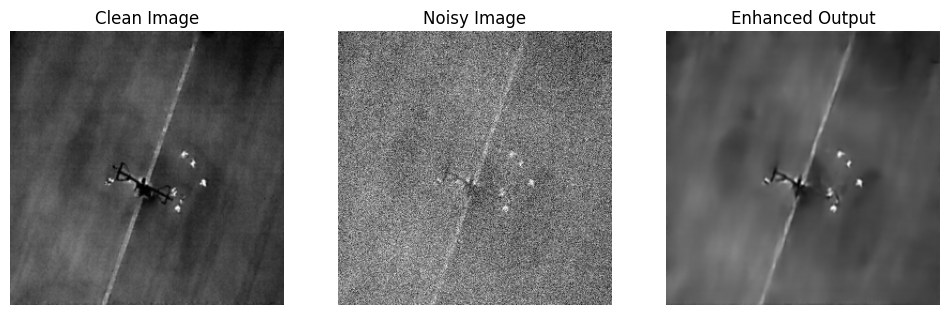

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(clean, cmap="gray")
plt.title("Clean Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noisy, cmap="gray")
plt.title("Noisy Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(output, cmap="gray")
plt.title("Enhanced Output")
plt.axis("off")

plt.show()

In [67]:
import torch.nn.functional as F
import math

def calculate_psnr(img1, img2):
    mse = F.mse_loss(img1, img2)
    if mse == 0:
        return 100
    return 20 * math.log10(1.0 / math.sqrt(mse))

psnr_value = calculate_psnr(
    clean.unsqueeze(0).unsqueeze(0).to(device),
    output.unsqueeze(0).unsqueeze(0).to(device)
)

print("Final PSNR:", psnr_value)

Final PSNR: 36.866179033538785


In [68]:
!pip install pytorch-msssim

In [69]:
from pytorch_msssim import ssim

ssim_value = ssim(
    clean.unsqueeze(0).unsqueeze(0).to(device),
    output.unsqueeze(0).unsqueeze(0).to(device),
    data_range=1.0
)

print("SSIM:", ssim_value.item())

SSIM: 0.9357195496559143


In [70]:
torch.save(model.state_dict(), "infrared_enhancement_model.pth")

In [72]:
plt.imsave("clean.png", clean.cpu(), cmap="gray")
plt.imsave("noisy.png", noisy.cpu(), cmap="gray")
plt.imsave("enhanced.png", output.cpu(), cmap="gray")

In [73]:
from google.colab import files

files.download("infrared_enhancement_model.pth")
files.download("clean.png")
files.download("noisy.png")
files.download("enhanced.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>